In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
import os
from hubble import hubble_fit
from hubble.hubble_fit import *
from hubble.hubble_utils import *
from hubble.hubble_likelihood import *
from hubble.hubble_plotting import *
from hubble.hubble_model import *
from hubble.hubble_completeness_refactored import *

CPU Num Cores: 6


In [2]:
from hubble.completeness_mock_catalog import (
    COSMO,
    build_shen_lf,
    mock_m_per_zbin,
    save_mock_catalog,
)

In [ ]:
# ----------------------------
# Load Pantheon
# ----------------------------
df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = hubble_fit.load_pantheon_data()


# --------------------------------------------------
# 1. Load AGN sample
# --------------------------------------------------
lc_fitting_results_file = "../data/mar16e_chisq_N1w2000s500t14ch4.h5.pkl"
spectra_fitting_results_file = "../data/results/data/jaxqsofit_mar15c.csv"

df_agn, df_agn_all = load_agn_data(
    lc_fitting_results_file,
    only_load=False,
    fhost_cut=10,
    spectra_fit_csv=[spectra_fitting_results_file],
    correct_sigma_uv_host=False,
    pickled=True,
)

# --------------------------------------------------
# 2. Generate Hopkins mock catalog
# --------------------------------------------------
phi_log10, m_grid, z_bins = build_shen_lf(None)

rng = np.random.default_rng(123)
_, nexp, _, nsel, z_all, m_all, m_2500_all, bin_index = mock_m_per_zbin(
    phi_log10,
    m_grid,
    z_bins,
    area_deg2=5.0,
    alpha_nu=-0.5,
    dalpha_nu=0.3,
    cosmo=COSMO,
    z_res=512,
    m_scatter=0.0,
    kcorr_zref=2.0,
    m_lim=28.0,
    rng=rng,
    return_z=True,
    return_global=True,
    verbose=True,
)

sim_file = "../data/mock_mag_z_hopkins.h5"
save_mock_catalog(sim_file, z_all, m_all, m_2500_all, m_limit=28.0)
print(f"Saved mock catalog: {sim_file}")
print(f"Generated {len(z_all)} mock sources before final save cut.")

# --------------------------------------------------
# 3. Build completeness map from that mock
# --------------------------------------------------
completeness2d, mag_centers, z_centers, dm, dz, sigma_mag = get_completeness_function_2d(
    df_agn,
    sim_file=sim_file,
    n_mag_bins=30,
    n_z_bins=40,
    smooth_counts=True,
    plot=True,
    fill_along_mag=False,
    fill_along_z=False,
)

print("Completeness sim file:", sim_file)
print("mag grid:", mag_centers.shape, mag_centers.min(), mag_centers.max())
print("z grid:", z_centers.shape, z_centers.min(), z_centers.max())
print("sigma_mag used:", sigma_mag)

Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Selected SNe: 1657 / 1701 (kept 1657; dropped 44).


In [ ]:
# ----------------------------
# Run joint AGN+SN fit
# ----------------------------
r = hubble_fit.run_single(
    df_agn=df_agn,
    df_agn_all=df_agn_all,
    df_pantheon=df_pantheon,
    _sna_L=_sna_L,
    _sna_Lower=_sna_Lower,
    _sna_LogdetCov=_sna_LogdetCov,
    cosmo_model="Flatw0waCDM",
    completeness=True,
    completeness_sim_file=sim_file,
    use_full_cov=True,
    speed="fast",                  # try "test" first if you want a lighter run
    only_sna=False,
    skip_plots=False,
    completeness_mode="3d",
    )

Saving plots to  plots/hubble/default/Flatw0waCDM_joint_fast_all_z0p44_3p16
Completeness enabled with mock catalog file: ../data/mock_mag_z_hopkins.h5

AGN pivot summary
--------------------------------------------------------------------
Quantity       Type                 log10 value    linear value
sigma_UV       computed mean            -0.7883          0.1628
tau_UV_RF      computed mean             2.6790        477.5368
sigma_UV       fixed pivot              -0.6990          0.2000
tau_UV_RF      fixed pivot               2.6990        500.0000
Running sampling with 9 parameters for cosmological model: Flatw0waCDM
Building 2d completeness map using mock catalog: ../data/mock_mag_z_hopkins.h5
Smoothing counts with sigma_mag=0.2 mag (sigma_mag/dm=1.0909090909091106), sigma_z=0.2 absolute z
Checkpoint file: results/hubble_posteriors/default/posteriors_Flatw0waCDM_joint_fast_all_z0p44_3p16.h5
Starting Hubble Fit with 8496 AGNs and 1657 SNes...
[Warning] Starting fast run...


562it [12:40,  1.35s/it, batch: 4 | bound: 3 | nc: 1 | ncall: 16574 | eff(%):  3.362 | loglstar: -6176.035 < -6172.803 < -6174.381 | logz: -6199.980 +/-  1.721 | stop:  0.790]      


Plotting full dynesty corner...

Bayesian evidence logZ = -6199.77 ± 1.51

Highest-weight (posterior) sample:
  idx: 489
  logl: -6176.035210572436
  weight: 0.022074475315458964
  (preview) integrals[:10]: [0.79178917 0.40804254 0.64411105 0.2530466  0.7198695  0.33216896
 0.34368246 0.84213954 0.3433842  0.82659274]

Median parameters (equal-weight posterior):
[-19.24484646 -22.13107915   5.87480023  -2.42146284  -0.32216746
  72.83153523   0.60424105  -0.43154889 -23.09800449]

Dynesty results stats:
  samples shape: (562, 9)
  blobs shape: (562, 2, 8496)
  weights max: 0.022074475315458964
  effective samples (ESS): 63.25789518306176
  resampled samples shape: (562, 9)
  resampled blobs shape: (562, 2, 8496)
1 sigma scatter on HD (magnitudes)
  sigma_intrinsic: 0.7245768425755011
Saved: ['flat_samples', 'dmi_max_w', 'logZ', 'logZerr', 'integrals_max_w'] to results/hubble_posteriors/default/posteriors_Flatw0waCDM_joint_fast_all_z0p44_3p16.h5
Plotting completeness diagnostics...
    

Using linear-z bins: [0.32 0.52 0.72 0.92 1.12 1.32 1.52 1.72 1.92 2.12 2.32 2.52 2.72 2.92
 3.12 3.32 3.52 3.72]
Note: 14 / 8728 AGN clipped in residuals panel (> 3σ)
Plotting binned AGN (linear z) at: [0.42 0.62 0.82 1.02 1.22 1.42 1.62 1.82 2.02 2.22 2.42 2.62 2.82 3.02
 3.22 3.42 3.62]
	mask_in: [False  True  True  True  True  True  True  True  True  True  True  True
  True  True False False False]
Plotting binned AGN (linear z) at: [0.42 0.62 0.82 1.02 1.22 1.42 1.62 1.82 2.02 2.22 2.42 2.62 2.82 3.02
 3.22 3.42 3.62]
	mask_out: [ True False False False False False False False False False False False
 False False  True  True  True]


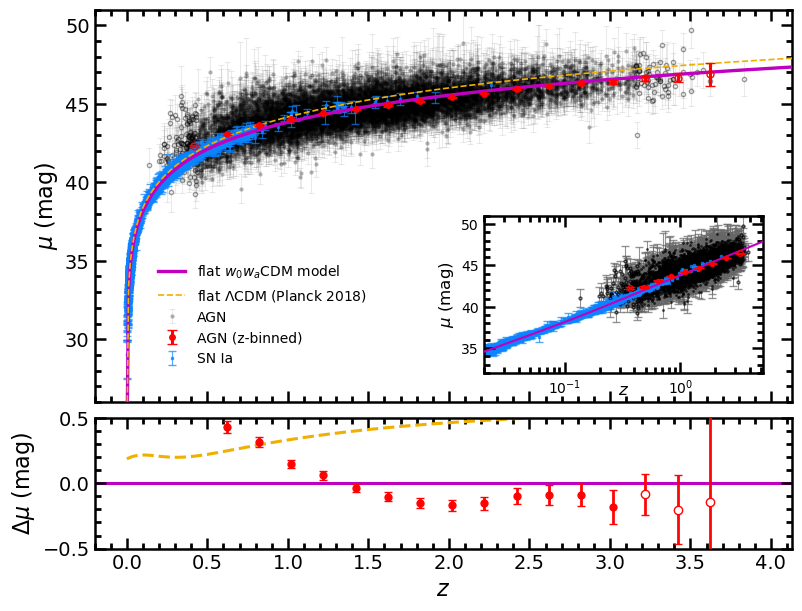

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4 (sorted by residual, largest last):
	z: 0.33 | object_id: 1414541 | npca_qso: N/A | SDSS: 013508.75+011450.0 | RA: 23.78646 | DEC: 1.24724 | Residual: 4.4
	z: 0.51 | object_id: 1450669 | npca_qso: N/A | SDSS: 231732.23+000346.5 | RA: 349.38430 | DEC: 0.06293 | Residual: 4.9
Residuals saved to plots/hubble/residuals.csv
Outliers (|residuals| > 5) saved to plots/hubble/outliers.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with mu_pred_std > 4:
	z: 0.51 | object_id: 1450669 | npca_qso: N/A | SDSS: 231732.23+000346.5 | RA: 349.38430 | DEC: 0.06293 | Residual: 4.9
	z: 0.33 | object_id: 1414541 | npca_qso: N/A | SDSS: 013508.75+011450.0 | RA: 23.78646 | DEC: 1.24724 | Residual: 4.4


(array([ 1.24499879, -0.36110778, -1.01069385, ...,  0.9008817 ,
         1.54548063,  0.17821954], shape=(8728,)),
 array([1.05000465, 1.18394747, 1.04960114, ..., 1.19615388, 1.00675805,
        1.00067309], shape=(8728,)),
 array([45.97997518, 46.43582468, 42.88870617, ..., 44.91560992,
        44.06369148, 44.76952289], shape=(8728,)),
 array([0.75936118, 0.93586925, 0.75880313, ..., 0.95126429, 0.6983419 ,
        0.68954063], shape=(8728,)),
 array([1.05000465, 1.18394747, 1.04960114, ..., 1.19615388, 1.00675805,
        1.00067309], shape=(8728,)))

In [ ]:
(
    flat_samples,
    model_labels,
    dm_interp,
    logZ,
    logZerr,
    debiased_residuals,
    age,
    age_err,
) = r

run_tag = hubble_fit.make_run_tag(
    cosmo_model="Flatw0waCDM",
    only_sna=False,
    speed="fast",      # match the value you used in run_single
    N=None,
    z_range=(0.44, 3.16),
)

hubble_fit.plot_hubble(
    flat_samples,
    df_agn,
    df_pantheon,
    cosmo_model="Flatw0waCDM",
    z_pivot_agn=hubble_fit.z_pivot_agn,
    show_true=False,
    show=True,
    debias=True,
    dm_interp=dm_interp,
    verbose=True,
)
